<a href="https://colab.research.google.com/github/Nikesh5005/ML_PROJ/blob/main/decision_tree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [30]:
from google.colab import drive
drive.mount('/content/drive')
%env OPENCODE_DATA_DIR=/content/drive/MyDrive/opencode-data

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
env: OPENCODE_DATA_DIR=/content/drive/MyDrive/opencode-data


In [31]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/WA_Fn-UseC_-HR-Employee-Attrition.csv')

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [33]:
df.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')

In [34]:
df.isnull().any()

,0
Age,False
Attrition,False
BusinessTravel,False
DailyRate,False
Department,False
DistanceFromHome,False
Education,False
EducationField,False
EmployeeCount,False
EmployeeNumber,False


In [35]:

num_col=df.select_dtypes(include='number').columns.to_list()
num_col


['Age',
 'DailyRate',
 'DistanceFromHome',
 'Education',
 'EmployeeCount',
 'EmployeeNumber',
 'EnvironmentSatisfaction',
 'HourlyRate',
 'JobInvolvement',
 'JobLevel',
 'JobSatisfaction',
 'MonthlyIncome',
 'MonthlyRate',
 'NumCompaniesWorked',
 'PercentSalaryHike',
 'PerformanceRating',
 'RelationshipSatisfaction',
 'StandardHours',
 'StockOptionLevel',
 'TotalWorkingYears',
 'TrainingTimesLastYear',
 'WorkLifeBalance',
 'YearsAtCompany',
 'YearsInCurrentRole',
 'YearsSinceLastPromotion',
 'YearsWithCurrManager']

In [36]:
df.duplicated().any()

np.False_

<Axes: xlabel='DistanceFromHome', ylabel='Attrition'>

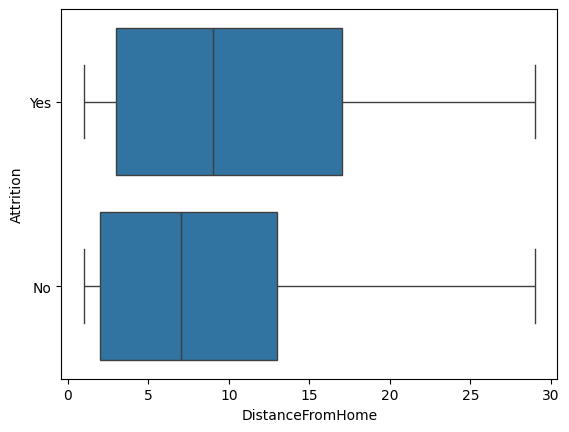

In [37]:
sns.boxplot(data=df,x='DistanceFromHome',y='Attrition')

In [57]:
pd.crosstab(df['JobRole'], df['Attrition'], normalize='index')

Attrition,No,Yes
JobRole,,
Healthcare Representative,0.931298,0.068702
Human Resources,0.769231,0.230769
Laboratory Technician,0.760618,0.239382
Manager,0.950980,0.049020
Manufacturing Director,0.931034,0.068966
Research Director,0.975000,0.025000
Research Scientist,0.839041,0.160959
Sales Executive,0.825153,0.174847
Sales Representative,0.602410,0.397590


so we can clearly see that JobRole is the strong predictor for deciding Attrition employee in job role like Sales Representative,Human Resources,Laboratory Technician are more likely to leave then other jobrole



<Axes: xlabel='MonthlyIncome'>

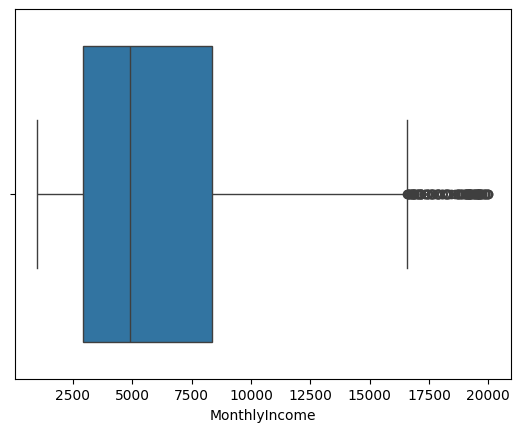

In [40]:
sns.boxplot(data=df, x='MonthlyIncome')

<Axes: xlabel='MonthlyIncome', ylabel='Attrition'>

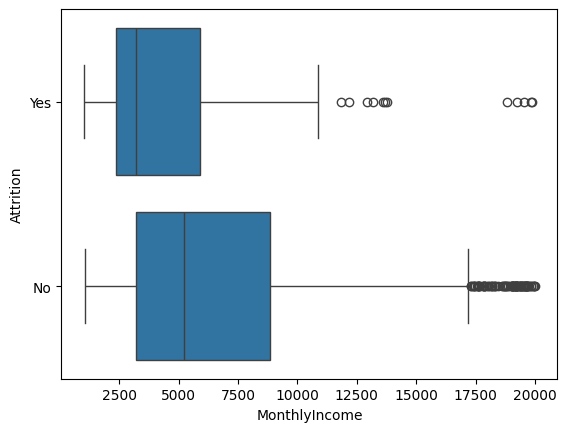

In [41]:
sns.boxplot(data=df, x='MonthlyIncome',y='Attrition')

we can clearly observe that employee who left  tend to have lower median MonthlyIncome then who said no(stayed)
this suggest that lower paid employee are more likely to leave and which also make a sense so monthly income can be a strong feature to decide wheather a employee stayed or not

<Axes: xlabel='MonthlyIncome', ylabel='Density'>

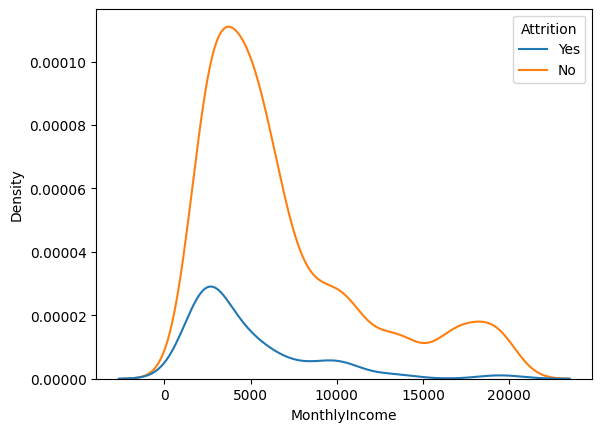

In [62]:
sns.kdeplot(data=df, x='MonthlyIncome',hue='Attrition')

In [61]:
df.groupby('JobLevel')['MonthlyIncome'].describe()

,count,mean,std,min,25%,50%,75%,max
JobLevel,,,,,,,,
1,543.0,2786.915285,748.634767,1009.0,2306.0,2670.0,3207.00,4968.0
2,534.0,5502.277154,1410.029686,2042.0,4544.0,5340.0,6273.50,9998.0
3,218.0,9817.252294,1805.999233,5210.0,8383.0,9980.0,10814.50,13757.0
4,106.0,15503.783019,1816.239003,11103.0,13761.0,16154.0,17036.25,17924.0
5,69.0,19191.826087,512.383127,18041.0,18880.0,19232.0,19586.00,19999.0


<Axes: xlabel='MonthlyIncome', ylabel='Density'>

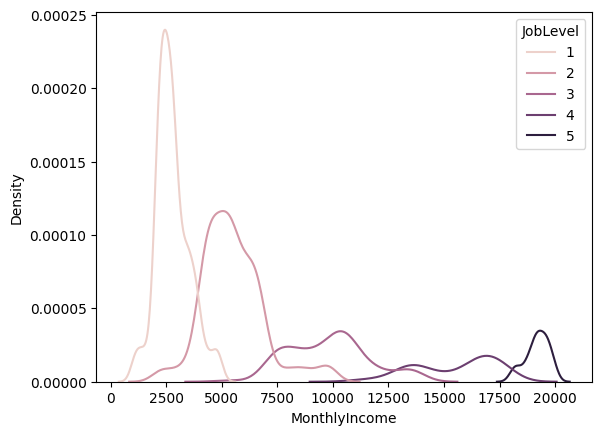

In [42]:
sns.kdeplot(data=df, x='MonthlyIncome',hue='JobLevel')

In [63]:
pd.crosstab(df['JobLevel'], df['Attrition'], normalize='index')

Attrition,No,Yes
JobLevel,,
1,0.736648,0.263352
2,0.902622,0.097378
3,0.853211,0.146789
4,0.952830,0.047170
5,0.927536,0.072464


since  MonthlyIncome is multimodel the peaks corresponds to  MonthlyIncome is found to be JobLevel so we can group MonthlyIncome by joblevel and found that enployee having  low joblevel have less  MonthlyIncome having  MonthlyIncome indicate hing chance of leaving .

,count,mean,std,min,25%,50%,75%,max
JobLevel,,,,,,,,
1,543.0,2786.915285,748.634767,1009.0,2306.0,2670.0,3207.00,4968.0
2,534.0,5502.277154,1410.029686,2042.0,4544.0,5340.0,6273.50,9998.0
3,218.0,9817.252294,1805.999233,5210.0,8383.0,9980.0,10814.50,13757.0
4,106.0,15503.783019,1816.239003,11103.0,13761.0,16154.0,17036.25,17924.0
5,69.0,19191.826087,512.383127,18041.0,18880.0,19232.0,19586.00,19999.0


<Axes: xlabel='OverTime', ylabel='count'>

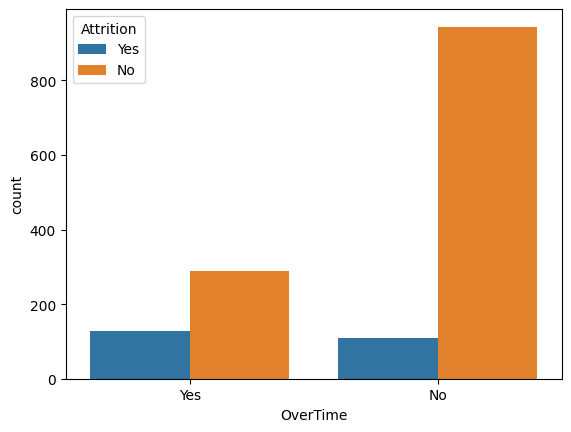

In [44]:
sns.countplot(data=df, x='OverTime', hue='Attrition')

In [45]:
output=df['Attrition']
input=df.drop(labels='Attrition',axis=1)

In [46]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    input, output, test_size=0.30, random_state=42)

In [47]:
input_cat_column=X_train.select_dtypes(include='object').columns.to_list()
input_num_column=X_train.select_dtypes(include='number').columns.to_list()

In [48]:
from sklearn.preprocessing import OneHotEncoder

In [49]:
encoder=OneHotEncoder(handle_unknown='ignore',sparse_output=False)

In [50]:
encoder.fit(X_train[input_cat_column])

OneHotEncoder(handle_unknown='ignore', sparse_output=False)

In [51]:
encoder.categories_

[array(['Non-Travel', 'Travel_Frequently', 'Travel_Rarely'], dtype=object),
 array(['Human Resources', 'Research & Development', 'Sales'], dtype=object),
 array(['Human Resources', 'Life Sciences', 'Marketing', 'Medical',
        'Other', 'Technical Degree'], dtype=object),
 array(['Female', 'Male'], dtype=object),
 array(['Healthcare Representative', 'Human Resources',
        'Laboratory Technician', 'Manager', 'Manufacturing Director',
        'Research Director', 'Research Scientist', 'Sales Executive',
        'Sales Representative'], dtype=object),
 array(['Divorced', 'Married', 'Single'], dtype=object),
 array(['Y'], dtype=object),
 array(['No', 'Yes'], dtype=object)]

In [52]:
encoded_col=list(encoder.get_feature_names_out(input_cat_column))
encoded_col

['BusinessTravel_Non-Travel',
 'BusinessTravel_Travel_Frequently',
 'BusinessTravel_Travel_Rarely',
 'Department_Human Resources',
 'Department_Research & Development',
 'Department_Sales',
 'EducationField_Human Resources',
 'EducationField_Life Sciences',
 'EducationField_Marketing',
 'EducationField_Medical',
 'EducationField_Other',
 'EducationField_Technical Degree',
 'Gender_Female',
 'Gender_Male',
 'JobRole_Healthcare Representative',
 'JobRole_Human Resources',
 'JobRole_Laboratory Technician',
 'JobRole_Manager',
 'JobRole_Manufacturing Director',
 'JobRole_Research Director',
 'JobRole_Research Scientist',
 'JobRole_Sales Executive',
 'JobRole_Sales Representative',
 'MaritalStatus_Divorced',
 'MaritalStatus_Married',
 'MaritalStatus_Single',
 'Over18_Y',
 'OverTime_No',
 'OverTime_Yes']

In [53]:
X_train_encoded=pd.DataFrame(encoder.transform(X_train[input_cat_column]),columns=encoded_col,index=X_train.index)
X_test_encoded=pd.DataFrame(encoder.transform(X_test[input_cat_column]),columns=encoded_col,index=X_test.index)

In [54]:
X_test=pd.concat([X_test,X_test_encoded],axis=1)
X_train=pd.concat([X_train,X_train_encoded],axis=1)

In [55]:
X_test=X_test.drop(labels=(input_cat_column),axis=1)
X_train=X_train.drop(labels=(input_cat_column),axis=1)

In [56]:
X_test

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Divorced,MaritalStatus_Married,MaritalStatus_Single,Over18_Y,OverTime_No,OverTime_Yes
1041,28,866,5,3,1,1469,4,84,3,2,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0
184,53,1084,13,2,1,250,4,57,4,2,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0
1222,24,240,22,1,1,1714,4,58,1,1,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0
67,45,1339,7,3,1,86,2,59,3,3,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0
220,36,1396,5,2,1,304,4,62,3,2,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1047,33,430,7,3,1,1477,4,54,3,2,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0
331,27,210,1,1,1,449,3,73,3,2,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0
323,28,1157,2,4,1,440,1,84,1,1,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0
654,39,1383,2,3,1,909,4,42,2,2,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0
